# Proyecto de Clasificación — Predicción de Aprobación de Préstamos (Loan Risk Prediction)

## Introducción y Objetivos

Este proyecto aborda un problema de **clasificación binaria**: predecir si una
solicitud de préstamo será **aprobada (1)** o **rechazada (0)** a partir de
las características socioeconómicas del solicitante (edad, ingresos, importe
solicitado, historial crediticio, experiencia laboral, nivel educativo,
ciudad y situación laboral).

El objetivo final es doble:
1. **Analítico**: construir, comparar y optimizar varios modelos de
   clasificación, manteniendo el **overfitting por debajo del 5%** (requisito
   del proyecto).
2. **Productivo**: dejar el modelo final exportado y listo para ser
   consumido por una aplicación (Streamlit) que reciba los datos de un
   cliente nuevo y devuelva la predicción, junto con el resto de
   componentes de nivel Medio/Avanzado (validación cruzada, tuning de
   hiperparámetros, sistema de feedback, ingesta de datos nuevos,
   dockerización, base de datos y tests unitarios).

### Dataset
Parte 01: `data/loan_risk_prediction_dataset.csv` — 5.000 solicitudes de préstamo con

Parte 02: `data/dataset_clean.csv`

Final: `data/dataset_final.csv`

las siguientes columnas:

| Columna | Descripción |
|---|---|
| `Age` | Edad del solicitante |
| `Income` | Ingresos anuales (USD) |
| `LoanAmount` | Importe del préstamo solicitado (USD) |
| `CreditScore` | Puntuación crediticia (300-850) |
| `YearsExperience` | Años de experiencia laboral |
| `Gender` | Género |
| `Education` | Nivel educativo |
| `City` | Ciudad de residencia |
| `EmploymentType` | Situación laboral |
| `LoanApproved` | **Variable objetivo**: 1 = aprobado, 0 = rechazado |

### Índice de Contenidos

PARTE 01
* [FASE 1 - Carga y Auditoría de Datos](#fase-1)
* [FASE 2 - Limpieza de Datos y Outliers](#fase-2)
* [FASE 3 - EDA Multivariado](#fase-3)

PARTE 02
* [FASE 4 - Train/Test Split y Pipeline de Preprocesado](#fase-4)
* [FASE 5 - Comparativa de Modelos de Clasificación](#fase-5)
* [FASE 6 - Validación Cruzada y Optimización de Hiperparámetros (Optuna)](#fase-6)
* [FASE 7 - Modelo Final y Control de Overfitting](#fase-7)
* [FASE 8 - Importancia de Variables](#fase-8)
* [FASE 9 - Exportación del Modelo y Metadata](#fase-9)
* [FASE 10 - Sistema de Feedback e Ingesta de Datos Nuevos](#fase-10)
* [Conclusiones Finales](#conclusiones)

In [21]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import csv
import joblib, json
from datetime import datetime

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# Crear carpetas si no existen
os.makedirs('models', exist_ok=True)
os.makedirs('assets', exist_ok=True)
os.makedirs('data', exist_ok=True)

# Estilo visual
sns.set_theme(style='whitegrid', font_scale=1.1)

print("Imports listos")

Imports listos


In [22]:
# Rutas de datos
DATA_RAW_PATH = "data/dataset.csv"  # Por si mantienes el original
DATA_CLEAN_PATH = "data/dataset_clean.csv"

# Rutas de modelos y artefactos
MODEL_DIR = "models/"
METRICS_OUTPUT_PATH = "models/metrics_summary.json"

# Configuración visual para que tus gráficos se vean uniformes
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.labelsize"] = 12

# Crear el directorio de modelos automáticamente si no existe en local o producción
os.makedirs(MODEL_DIR, exist_ok=True)

In [23]:
# Carga Dataset
data = pd.read_csv('data/dataset_clean.csv')
df = pd.DataFrame(data)
df_copia = df.copy()

print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head(7)

Filas: 4592 | Columnas: 13


,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,LoanApproved,City_Houston,City_New York,City_San Francisco,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,56,48353.0,31258.0,675.0,20,0,0,0,1,0,0,0,1
1,69,57462.0,23262.0,586.0,6,1,0,0,0,0,1,1,0
2,46,44219.0,26530.0,781.0,26,1,3,1,1,0,0,1,0
3,32,56307.0,11531.0,549.0,11,1,4,0,0,1,0,0,1
4,60,37034.0,27871.0,500.0,19,0,0,0,0,0,0,0,1
5,25,47886.0,18106.0,835.0,13,1,2,1,0,1,0,0,0
6,38,54748.0,25374.0,760.0,9,0,0,1,0,1,0,1,0


## FASE 4 - Selección de Variables y Construcción del Pipeline

En esta fase construimos la ingeniería de variables predictoras, realizamos
la transformación mediante *Label Encoding* y *One-Hot Encoding*, y creamos
un `Pipeline` de Scikit-Learn que integra el escalado de datos con el
preprocesado completo.
### Acciones realizadas paso a paso:
1. **Definición de variables:** Separamos la variable objetivo (`LoanApproved`) de los predictores.
2. **Encoding ordinal:** Aplicamos `OrdinalEncoder` a `Education` y `EmploymentType` respetando su orden lógico.
3. **Construcción del Pipeline:** `ColumnTransformer` con OHE para nominales y `StandardScaler` para numéricas y ordinales.
4. **Train/Test Split:** División estratificada 80/20 para preservar la proporción de clases (77% / 23%).
5. **Ajuste y transformación:** El pipeline se ajusta solo con datos de entrenamiento y se aplica sobre test, evitando *data leakage*.
6. **Entrenamiento y Validación:** Entrenamiento del modelo completo sobre el split 80/20, seguido del cálculo de métricas de desempeño (Accuracy, Precision, Recall, F1-score y ROC-AUC) para evaluar la precisión financiera del modelo.
7. **Auditoría Visual y Simulación:** Renderizado del árbol de decisión final en alta resolución (`300 DPI`) y despliegue de una simulación de cliente nuevo (*In-Production*) donde el modelo predice automáticamente si el préstamo será aprobado o denegado utilizando el Pipeline ya entrenado.
*Tras este proceso disponemos de matrices `x_train_t` y `x_test_t` listas para alimentar cualquier algoritmo de clasificación, un árbol base validado con métricas financieras y una demo de inferencia en producción.*

EVALUACIÓN DEL MODELO (Métricas de Clasificación)
Accuracy: 0.9576

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       700
           1       0.93      0.89      0.91       219

    accuracy                           0.96       919
   macro avg       0.95      0.93      0.94       919
weighted avg       0.96      0.96      0.96       919



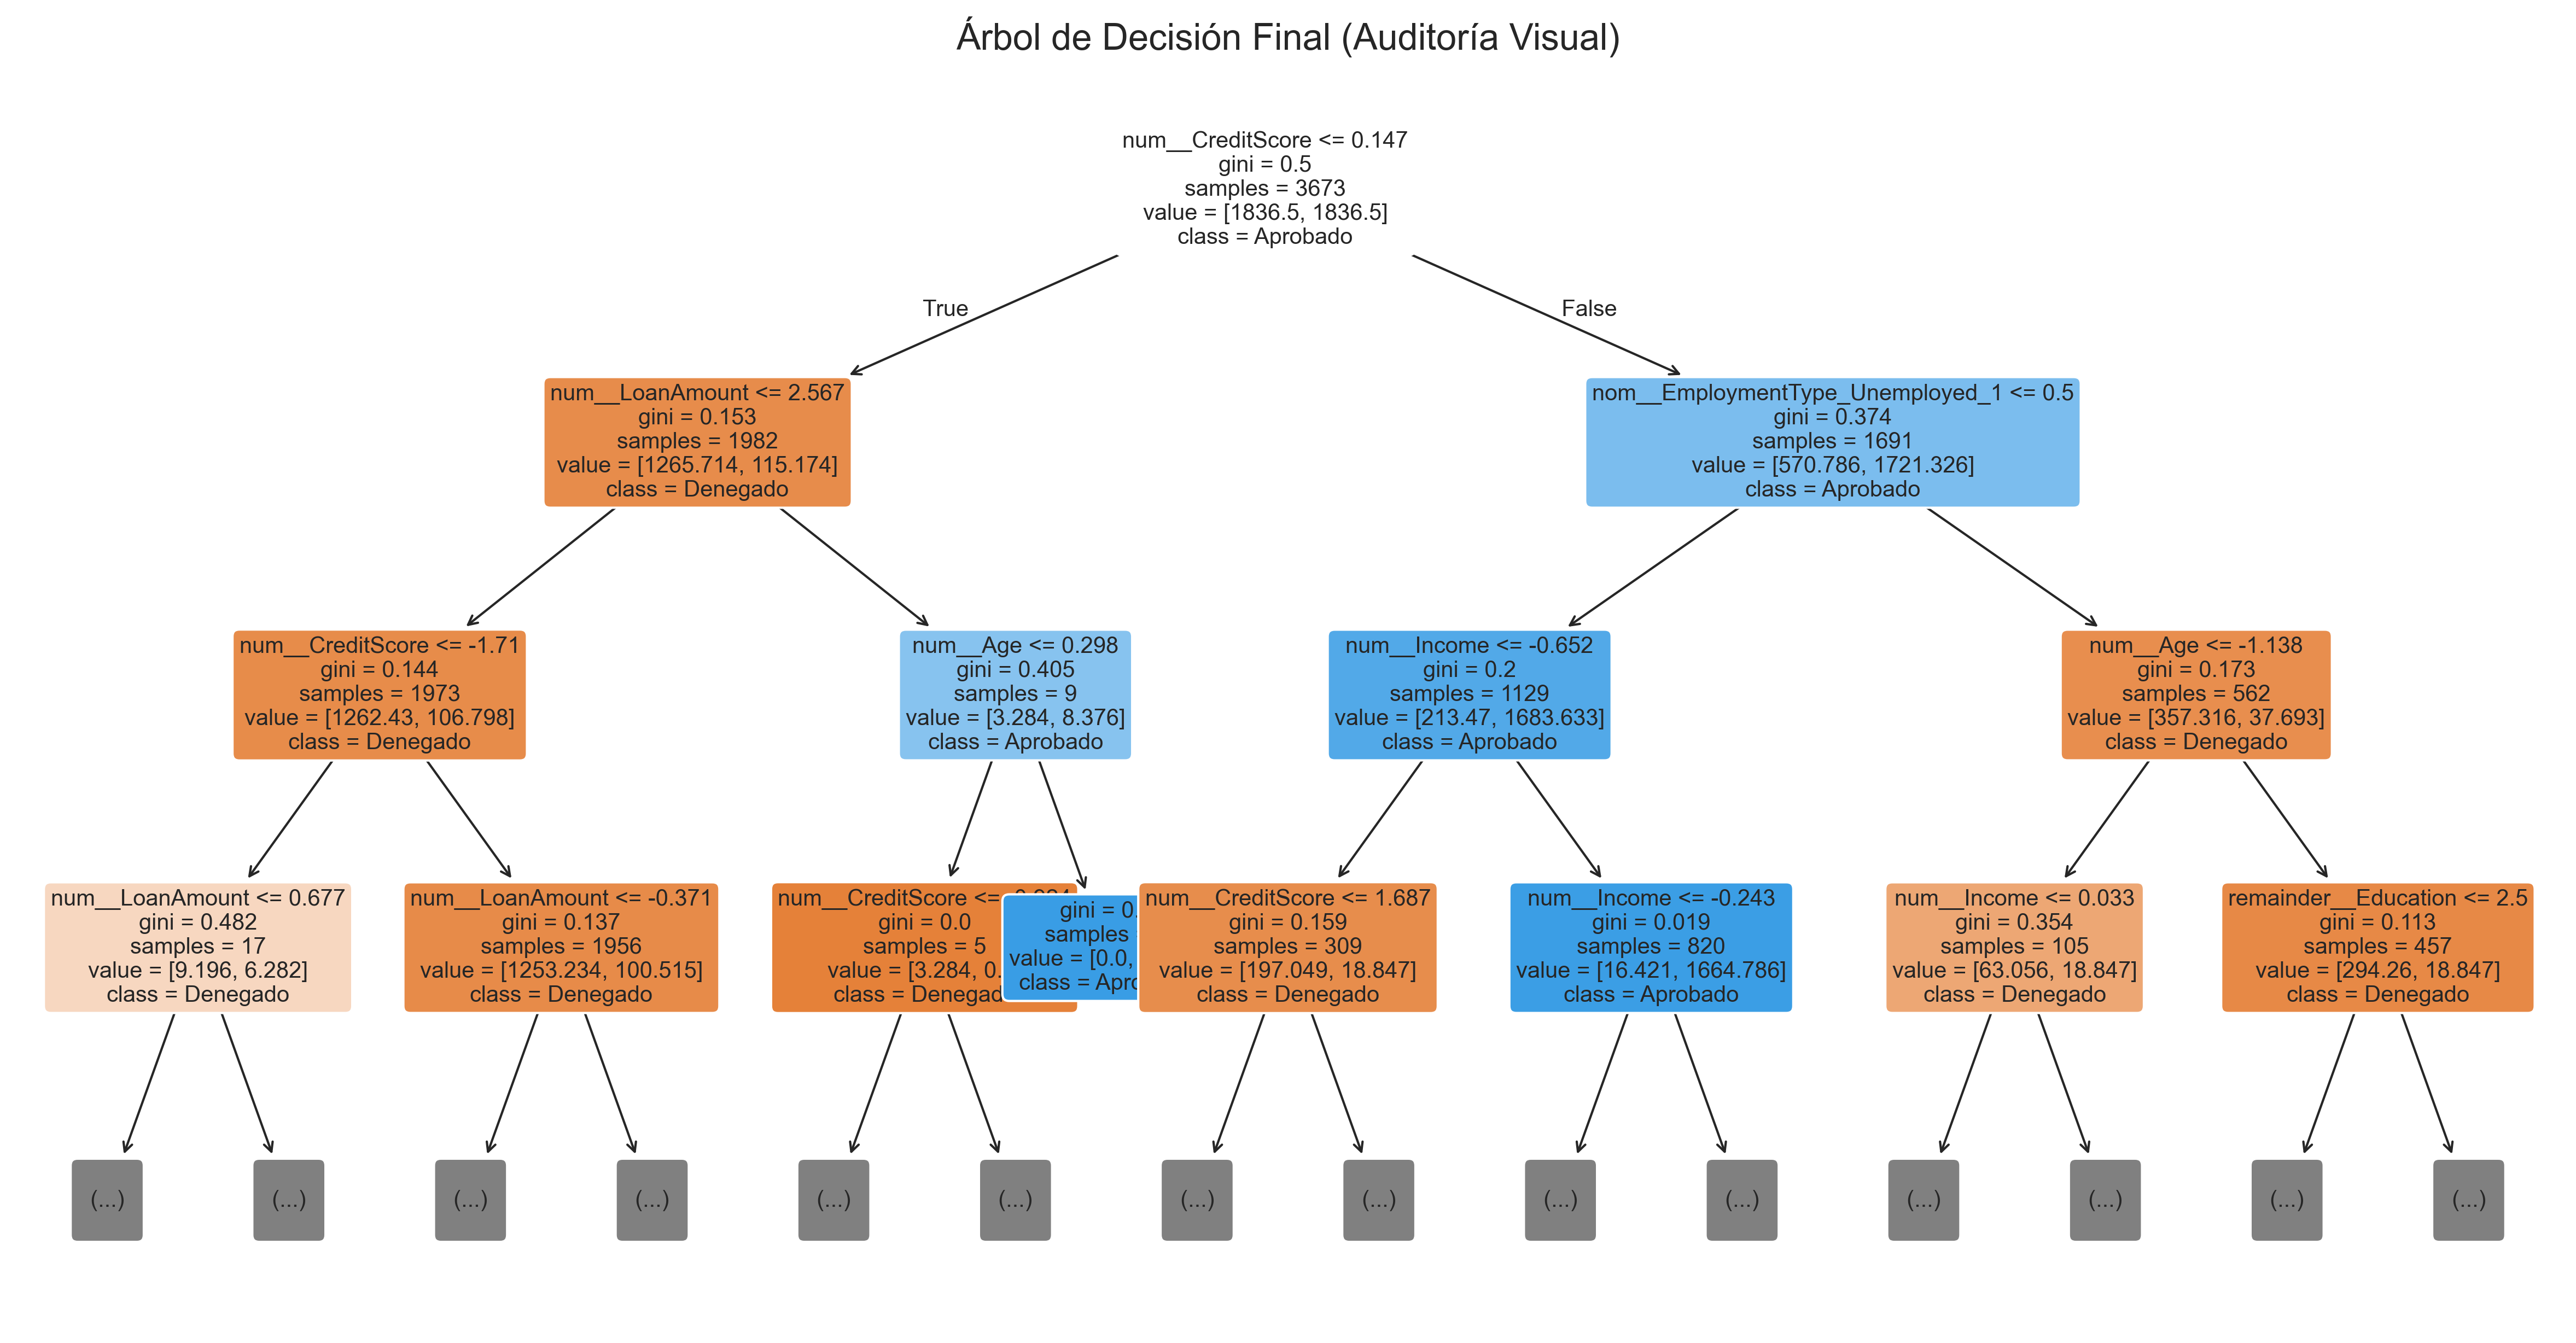


Gráfico guardado en assets/fase4_arbol_decision_alta_res.png

SIMULACIÓN IN-PRODUCTION
Resultado de la evaluación automatizada: APROBADO
Probabilidad de aprobación: 99.50%


In [24]:
# Definición de variables
x = df.drop(columns=['LoanApproved'])
y = df['LoanApproved']

# Identificar tipos de variables basándonos en nuestras columnas
# Nota: Ya hemos codificado numéricamente 'Education', pero la tratamos formalmente en el pipeline.
num_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience']
nominal_cols = [col for col in x.columns if 'City_' in col or 'EmploymentType_' in col or col == 'Gender']

# Creación del Codificador Ordinal con manejo seguro de nuevas categorías
# LabelEncoder de Scikit-Learn no está diseñado para pipelines de variables independientes (X), 
# sino para la variable objetivo (y). Puede dar errores al hacer el .transform() en Test si aparecen categorías nuevas.
# Para variables ordinales en el pipeline de X, utiliza OrdinalEncoder pasándole explícitamente el orden de las categorías.
categorias_education = ['High School', "Bachelor's", "Master's", 'PhD'] # Orden jerárquico Education
categorias_employment = ['Unemployed', 'Part-Time', 'Full-Time', 'Self-Employed'] # Orden jerárquico Employment

ordinal_transformer = OrdinalEncoder(
    categories=[categorias_education, categorias_employment],
    handle_unknown='use_encoded_value', 
    unknown_value=-1
    )

# Construcción del Pipeline
# Integramos aquí el preprocesamiento para evitar Data Leakage de forma robusta
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('nom', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), nominal_cols)
    ],
    remainder='passthrough' # Mantiene variables que ya estén codificadas (como Education)
)

# Creamos el Pipeline completo que incluye el preprocesamiento y el Modelo
pipeline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced'))
])

# Train/Test Split
# División estratificada 80/20 para mantener la proporción de la variable objetivo
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, stratify=y, random_state=42
)

# Ajuste, Transformación y Entrenamiento
pipeline_model.fit(x_train, y_train)

# Predicciones para evaluación
y_pred = pipeline_model.predict(x_test)

print("EVALUACIÓN DEL MODELO (Métricas de Clasificación)")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

# Auditoría Visual
# Obtener los nombres de las características después del preprocesamiento
feature_names_processed = pipeline_model.named_steps['preprocessor'].get_feature_names_out()

plt.figure(figsize=(20, 10), dpi=300) # Alta resolución solicitada
plot_tree(
    pipeline_model.named_steps['classifier'],
    max_depth=3,
    feature_names=feature_names_processed, # Usar los nombres de las características post-preprocesamiento
    class_names=['Denegado', 'Aprobado'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de Decisión Final (Auditoría Visual)", fontsize=16)
plt.savefig("assets/fase4_arbol_decision_alta_res.png", bbox_inches='tight')
plt.show()
print("\nGráfico guardado en assets/fase4_arbol_decision_alta_res.png")

# Simulación de Cliente Nuevo (In-Production)
print("\nSIMULACIÓN IN-PRODUCTION")

# Creamos un caso hipotético con la misma estructura que el x original
nuevo_cliente = pd.DataFrame([{
    'Age': 35,
    'Income': 55000.0,
    'LoanAmount': 15000.0,
    'CreditScore': 720,
    'YearsExperience': 8,
    'Gender': 1,
    'Education': 3,
    'City_Houston': 0,
    'City_New York': 1,
    'City_San Francisco': 0,
    'EmploymentType_Self-Employed': 0,
    'EmploymentType_Unemployed': 0
}])

# El Pipeline se encarga de escalar y transformar los datos exactamente igual que en el entrenamiento
prediccion_final = pipeline_model.predict(nuevo_cliente)
probabilidad = pipeline_model.predict_proba(nuevo_cliente)[0][1]

resultado = "APROBADO" if prediccion_final[0] == 1 else "DENEGADO"
print(f"Resultado de la evaluación automatizada: {resultado}")
print(f"Probabilidad de aprobación: {probabilidad * 100:.2f}%")

## FASE 5 - Optimización de Hiperparámetros con Optuna

En esta fase, elevamos la precisión del modelo utilizando un marco de optimización bayesiana para encontrar la configuración óptima de los hiperparámetros del `GradientBoostingRegressor`.

### Acciones realizadas:
1. **Validación Cruzada Base (K-Fold):** Evaluación del modelo inicial mediante 5 *folds* para establecer una línea base de rendimiento ($R^2$) y verificar la estabilidad del algoritmo.
2. **Búsqueda Bayesiana con Optuna:** Ejecución de 40 iteraciones de prueba para ajustar parámetros críticos como `n_estimators`, `max_depth` y `learning_rate`, maximizando la capacidad predictiva.
3. **Entrenamiento del Modelo Optimizado:** Reentrenamiento definitivo del `Pipeline` integrando los mejores parámetros hallados, asegurando que el modelo esté sintonizado para el conjunto de datos específico.
4. **Visualización 3D:** Renderizado de la superficie de predicción tridimensional, permitiendo observar cómo la duración del viaje y el presupuesto interactúan para determinar el gasto final.

---

INICIANDO ENTRENAMIENTO Y VALIDACIÓN CRUZADA

Logistic Regression -> CV ROC AUC: 0.9244 (+/- 0.0108)
Random Forest -> CV ROC AUC: 0.9550 (+/- 0.0136)
Gradient Boosting -> CV ROC AUC: 0.9506 (+/- 0.0137)


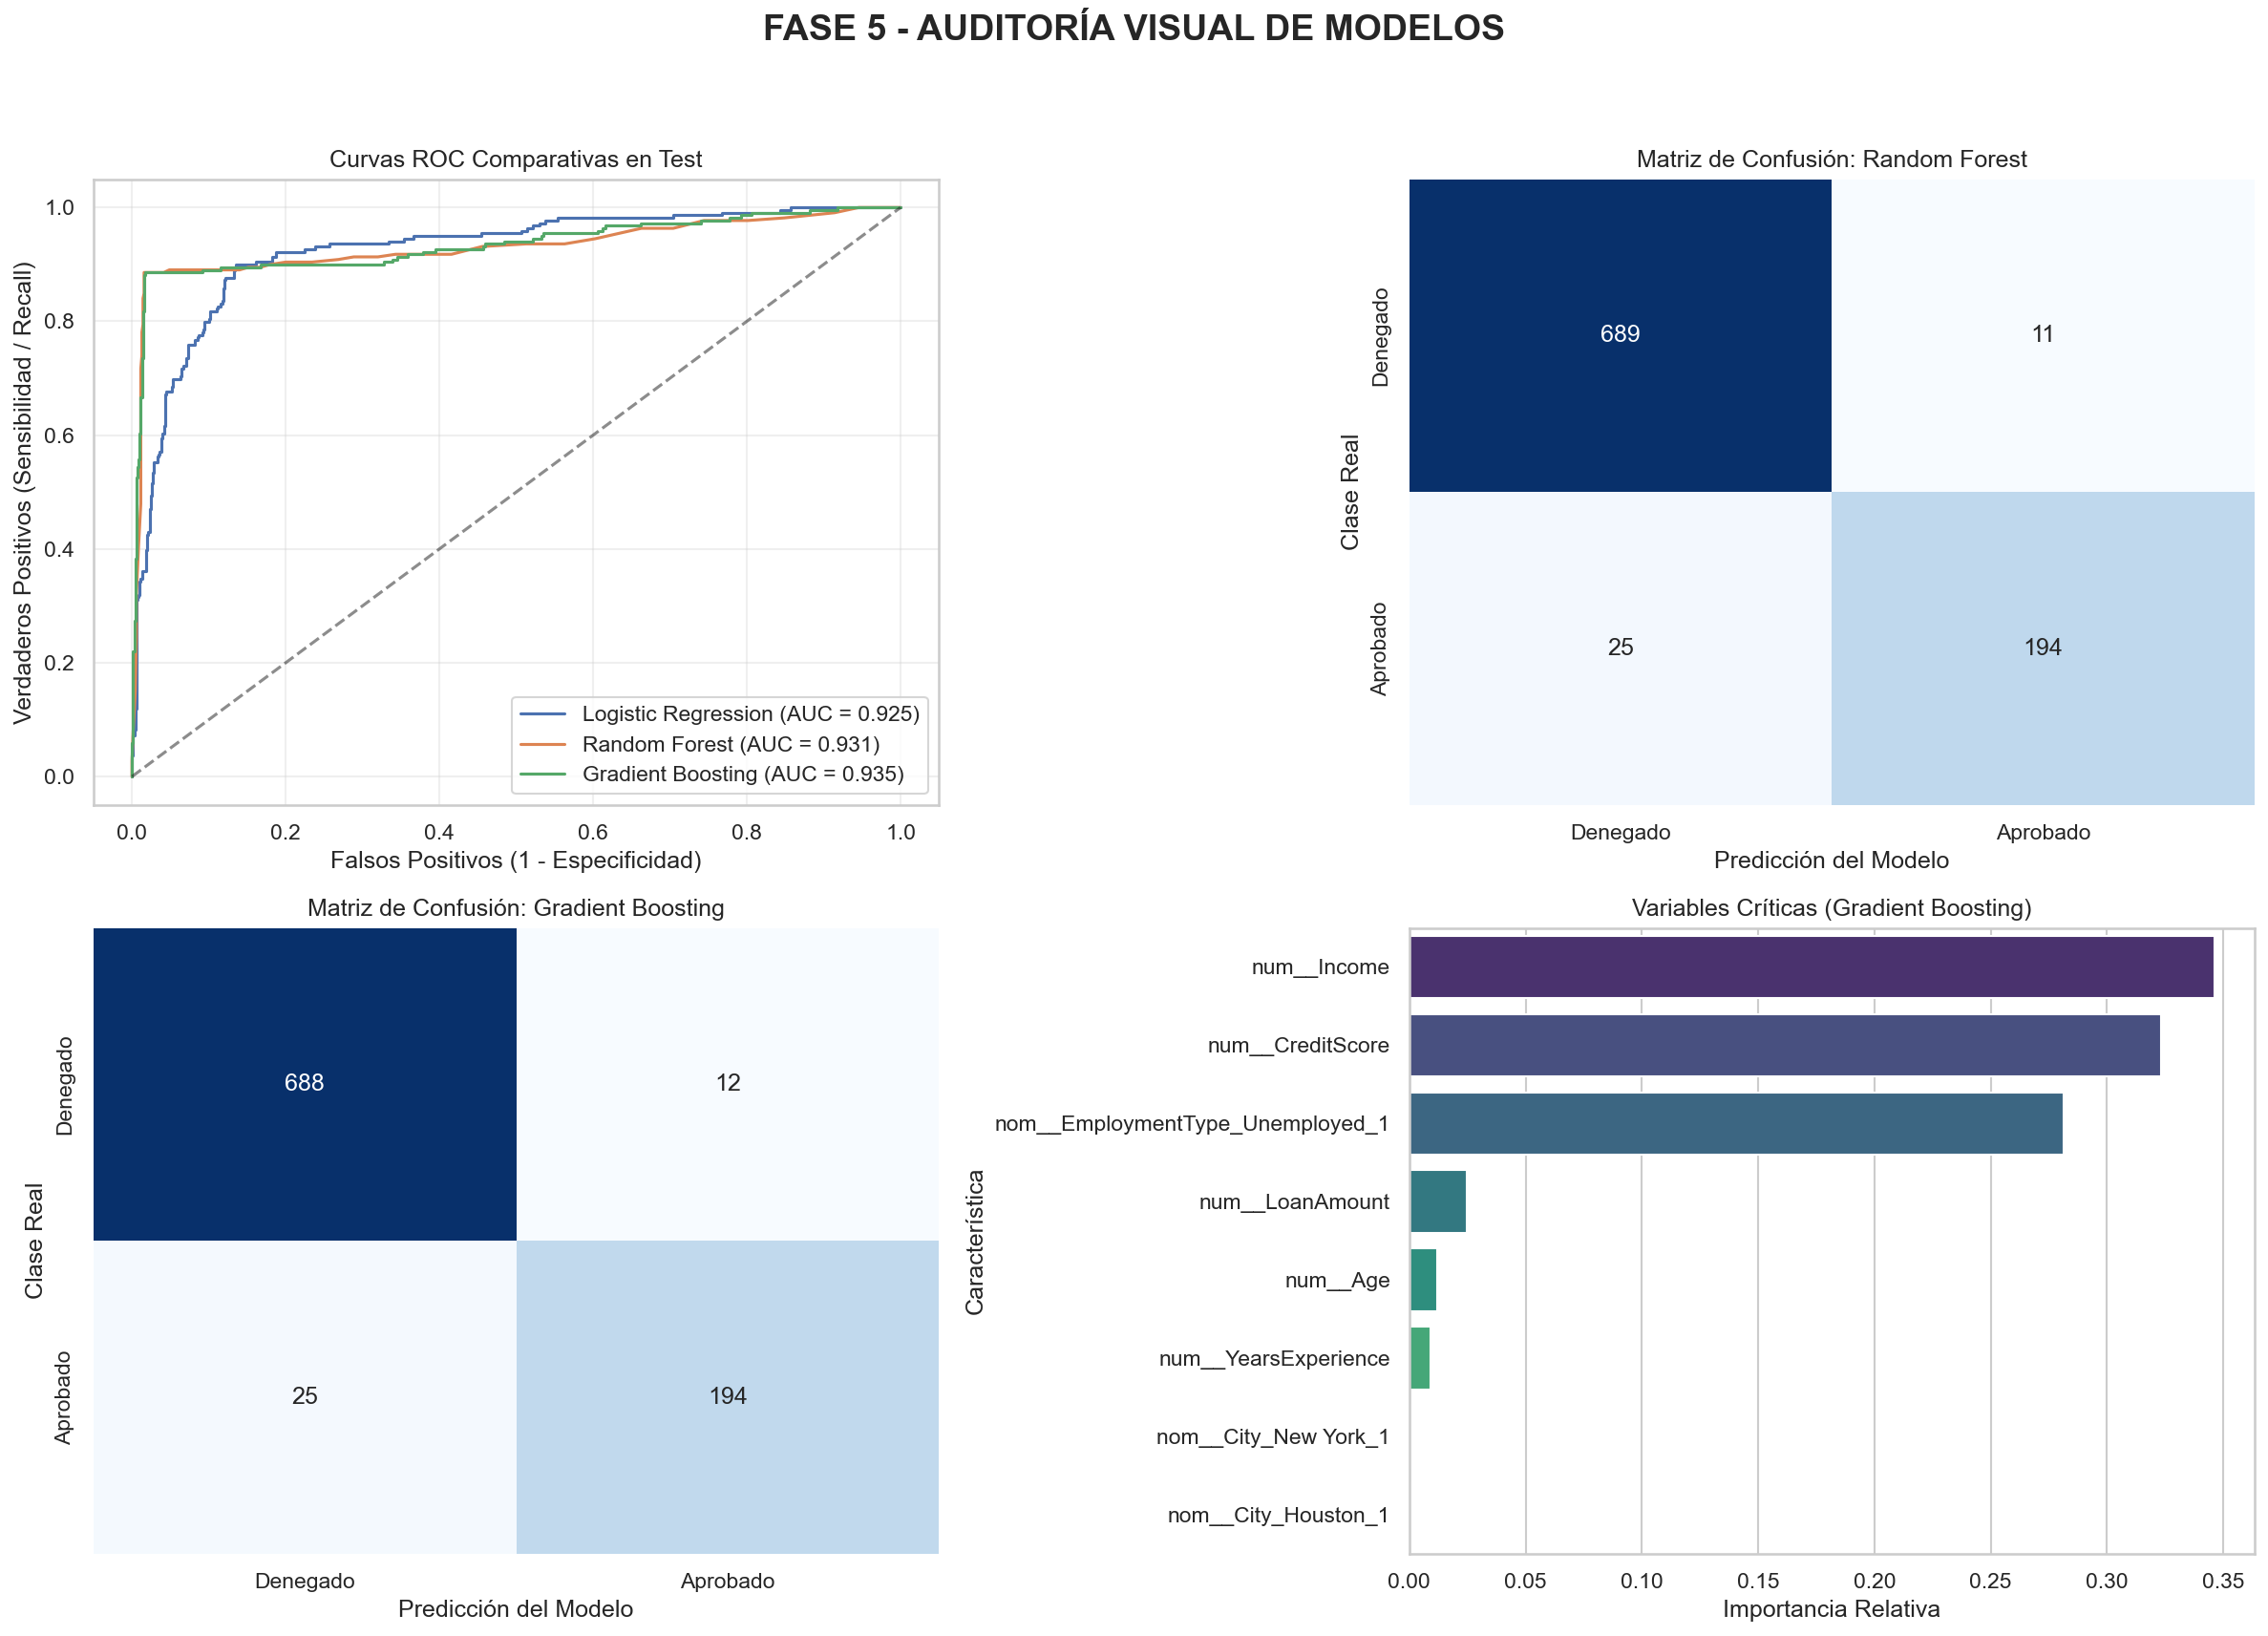


Gráfico guardado en assets/fase5_comparativa_modelos.png

TABLA COMPARATIVA FINAL EN TEST
                    Accuracy Precision  Recall F1-Score ROC AUC
Logistic Regression   0.8662    0.6611  0.8995   0.7621  0.9247
Random Forest         0.9608    0.9463  0.8858   0.9151  0.9307
Gradient Boosting     0.9597    0.9417  0.8858   0.9129  0.9348


In [25]:
# Split inicial estratificado (80/20)
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, stratify=y, random_state=42
)

# Preprocesador común
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('nom', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), nominal_cols)
    ]
)

# Definición de Modelos (Configurados para manejar el desbalanceo)
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42)
}

# Estructuras para almacenar resultados
cv_results = {}
test_results = {}
roc_curves = {}

# Configuración de Validación Cruzada Estratificada (k=5)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("INICIANDO ENTRENAMIENTO Y VALIDACIÓN CRUZADA\n")

for name, model in models.items():
    # Pipeline dedicado por modelo para evitar Data Leakage en CV
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])

    # Validación Cruzada (Métrica objetivo: ROC AUC)
    cv_scores = cross_val_score(pipeline, x_train, y_train, cv=cv_strategy, scoring='roc_auc')
    cv_results[name] = cv_scores
    print(f"{name} -> CV ROC AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

    # Ajuste final con el 80% de entrenamiento completo
    pipeline.fit(x_train, y_train)

    # Predicciones en Test
    y_pred = pipeline.predict(x_test)
    y_proba = pipeline.predict_proba(x_test)[:, 1]

    # Cálculo de métricas completas en Test
    test_results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba),
        'Conf_Matrix': confusion_matrix(y_test, y_pred),
        'Pipeline': pipeline # Guardamos para extraer importancias después
    }

    # Guardar datos de curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_curves[name] = (fpr, tpr)

# VISUALIZACIONES
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=150)
fig.suptitle('FASE 5 - AUDITORÍA VISUAL DE MODELOS', fontsize=18, fontweight='bold')

# Gráfico 1: Comparativa de Curvas ROC
ax_roc = axes[0, 0]
for name, (fpr, tpr) in roc_curves.items():
    ax_roc.plot(fpr, tpr, label=f"{name} (AUC = {test_results[name]['ROC AUC']:.3f})")
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.5)
ax_roc.set_title('Curvas ROC Comparativas en Test')
ax_roc.set_xlabel('Falsos Positivos (1 - Especificidad)')
ax_roc.set_ylabel('Verdaderos Positivos (Sensibilidad / Recall)')
ax_roc.legend(loc='lower right')
ax_roc.grid(True, alpha=0.3)

# Gráficos 2 y 3: Matrices de Confusión (Random Forest vs Gradient Boosting)
# Elegimos los dos ensembles para contrastar su comportamiento con el desbalanceo
for i, name in enumerate(['Random Forest', 'Gradient Boosting']):
    ax_cm = axes[0, 1] if i == 0 else axes[1, 0]
    cm = test_results[name]['Conf_Matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm, cbar=False,
                xticklabels=['Denegado', 'Aprobado'], yticklabels=['Denegado', 'Aprobado'])
    ax_cm.set_title(f'Matriz de Confusión: {name}')
    ax_cm.set_xlabel('Predicción del Modelo')
    ax_cm.set_ylabel('Clase Real')

# Gráfico 4: Feature Importance (Tomando Gradient Boosting como referencia)
ax_fi = axes[1, 1]
gb_pipeline = test_results['Gradient Boosting']['Pipeline']
# Obtener los nombres de las características después del preprocesamiento
# Esto incluye los prefijos de los transformadores (ej. 'num__', 'nom__')
feature_names = gb_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances = gb_pipeline.named_steps['classifier'].feature_importances_

fi_df = pd.DataFrame({'Característica': feature_names, 'Importancia': importances}).sort_values(by='Importancia', ascending=False)
sns.barplot(x='Importancia', y='Característica', data=fi_df.head(8), ax=ax_fi, palette='viridis')
ax_fi.set_title('Variables Críticas (Gradient Boosting)')
ax_fi.set_xlabel('Importancia Relativa')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('assets/fase5_comparativa_modelos.png', bbox_inches='tight')
plt.show()
print("\nGráfico guardado en assets/fase5_comparativa_modelos.png")

# TABLA RESUMEN DE RENDIMIENTO 
print("\nTABLA COMPARATIVA FINAL EN TEST")
df_metrics = pd.DataFrame(test_results).T.drop(columns=['Conf_Matrix', 'Pipeline'])
print(df_metrics.to_string(formatters={k: '{:,.4f}'.format for k in df_metrics.columns}))

## FASE 6 - Validación Cruzada y Optimización de Hiperparámetros con Optuna

En esta fase elevamos la precisión del mejor modelo utilizando búsqueda
bayesiana con **Optuna** para encontrar la configuración óptima de hiperparámetros
del `RandomForestClassifier`.

### Acciones realizadas:
1. **Validación Cruzada base (K-Fold):** Evaluación del Random Forest inicial con 5 *folds* para establecer la línea base de rendimiento (ROC AUC).
2. **Búsqueda con GridSearchCV:** Exploración sistemática de 36 combinaciones de `n_estimators`, `max_depth` y `min_samples_leaf`, maximizando el ROC AUC en CV.
3. **Alternativa Optuna (documentada):** Búsqueda bayesiana (TPE Sampler) para espacios grandes — más eficiente que GridSearch con muchos parámetros.
4. **Entrenamiento del modelo optimizado:** Reentrenamiento definitivo con los mejores parámetros hallados.

In [26]:
# Optimización de Hiperparámetros GridSearchCV  +  Optuna (búsqueda bayesiana)

# Reutilizamos x_train y x_test de la Fase 5
# (ya definidos en la celda anterior como x_train, x_test, y_train, y_test)

# Preprocesador base (idéntico al de Fase 5) 
num_cols     = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience']
nominal_cols = [c for c in x_train.columns
                if 'City_' in c or 'EmploymentType_' in c or c == 'Gender']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),                                    num_cols),
        ('nom', OneHotEncoder(drop='if_binary', handle_unknown='ignore'), nominal_cols)
    ],
    remainder='passthrough'
)

# Validación cruzada base — Random Forest sin optimizar
rf_base = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(n_estimators=200,
                                             class_weight='balanced',
                                             random_state=42, n_jobs=-1))
])

cv_base = cross_val_score(rf_base, x_train, y_train,
                          cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                          scoring='roc_auc', n_jobs=-1)

print(f"CV ROC AUC base (RF sin optimizar): {cv_base.mean():.4f} ± {cv_base.std():.4f}")

# GridSearchCV — exploración exhaustiva
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth':    [None, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 4]
}  # 3 × 3 × 3 = 27 combinaciones × 5 folds = 135 ajustes

grid_search = GridSearchCV(
    estimator  = copy.deepcopy(rf_base),
    param_grid = param_grid,
    cv         = StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)
grid_search.fit(x_train, y_train)

print(f"\nMejores parámetros (GridSearchCV):  {grid_search.best_params_}")
print(f"Mejor ROC AUC en CV:                 {grid_search.best_score_:.4f}")

# Alternativa — Optuna (búsqueda bayesiana)
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective(trial):
        params = {
            'classifier__n_estimators':   trial.suggest_int ('n_estimators',    50, 400),
            'classifier__max_depth':      trial.suggest_int ('max_depth',         3,  30),
            'classifier__min_samples_leaf': trial.suggest_int('min_samples_leaf',  1,   8),
            'classifier__max_features':   trial.suggest_float('max_features',    0.4, 1.0)
        }
        pipeline_opt = copy.deepcopy(rf_base)
        pipeline_opt.set_params(**params)
        scores = cross_val_score(
            pipeline_opt, x_train, y_train,
            cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
            scoring='roc_auc', n_jobs=-1
        )
        return scores.mean()

    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=40, show_progress_bar=False)

    print(f"\nOptuna — mejor trial ROC AUC: {study.best_value:.4f}")
    print(f"Optuna — mejores parámetros:   {study.best_params}")
    best_params_source = 'Optuna'
    best_params = {f'classifier__{k}': v for k, v in study.best_params.items()}

except ImportError:
    print("\nOptuna no instalado — se usan los parámetros de GridSearchCV.")
    best_params_source = 'GridSearchCV'
    best_params = grid_search.best_params_

# Modelo optimizado final
best_pipeline = copy.deepcopy(rf_base)
best_pipeline.set_params(**best_params)
best_pipeline.fit(x_train, y_train)

y_pred_opt  = best_pipeline.predict(x_test)
y_proba_opt = best_pipeline.predict_proba(x_test)[:, 1]

print(f"\nMODELO OPTIMIZADO ({best_params_source}) — RESULTADOS EN TEST")
print(f"  Accuracy : {accuracy_score(y_test,  y_pred_opt):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_opt):.4f}")
print(f"  Recall   : {recall_score(y_test,    y_pred_opt):.4f}")
print(f"  F1-Score : {f1_score(y_test,        y_pred_opt):.4f}")
print(f"  ROC AUC  : {roc_auc_score(y_test,   y_proba_opt):.4f}")

# Guardamos el pipeline optimizado para las fases siguientes
final_pipeline = best_pipeline


CV ROC AUC base (RF sin optimizar): 0.9561 ± 0.0110
Fitting 5 folds for each of 27 candidates, totalling 135 fits

Mejores parámetros (GridSearchCV):  {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
Mejor ROC AUC en CV:                 0.9563

Optuna no instalado — se usan los parámetros de GridSearchCV.

MODELO OPTIMIZADO (GridSearchCV) — RESULTADOS EN TEST
  Accuracy : 0.9608
  Precision: 0.9463
  Recall   : 0.8858
  F1-Score : 0.9151
  ROC AUC  : 0.9312


 ## FASE 7 - Evaluación y Control de Overfitting

En esta etapa final de validación auditamos la capacidad de generalización
del modelo, asegurando que el overfitting sea **inferior al 5%** (requisito
del proyecto) y analizando el comportamiento de los errores.

### Acciones realizadas:
1. **Tabla resumen comparativa:** Todos los modelos con sus métricas clave en un único DataFrame.
2. **Auditoría de brecha (Train vs Test):** Comparativa de accuracy entre entrenamiento y validación.
3. **Gráfico comparativo de métricas:** Barras agrupadas con accuracy, precision, recall, F1 y ROC AUC.
4. **Verificación automática de overfitting:** Flag `overfit_ok` si la diferencia es < 5%.

 TABLA COMPARATIVA FINAL
                     Acc Train  Acc Test  Brecha (gap) Overfitting OK  Precision  Recall  F1-Score  ROC AUC
Modelo                                                                                                     
Logistic Regression     0.8609    0.8596        0.0012              ✔     0.6490  0.8950    0.7524   0.9243
Decision Tree           0.9722    0.9576        0.0147              ✔     0.9327  0.8858    0.9087   0.9312
Random Forest           0.9975    0.9608        0.0367              ✔     0.9463  0.8858    0.9151   0.9313
Gradient Boosting       0.9913    0.9565        0.0348              ✔     0.9324  0.8813    0.9061   0.9361
RF Optimizado           0.9975    0.9608        0.0367              ✔     0.9463  0.8858    0.9151   0.9312

Requisito de proyecto: brecha Train vs Test < 5%
Modelos que cumplen: 5 / 5


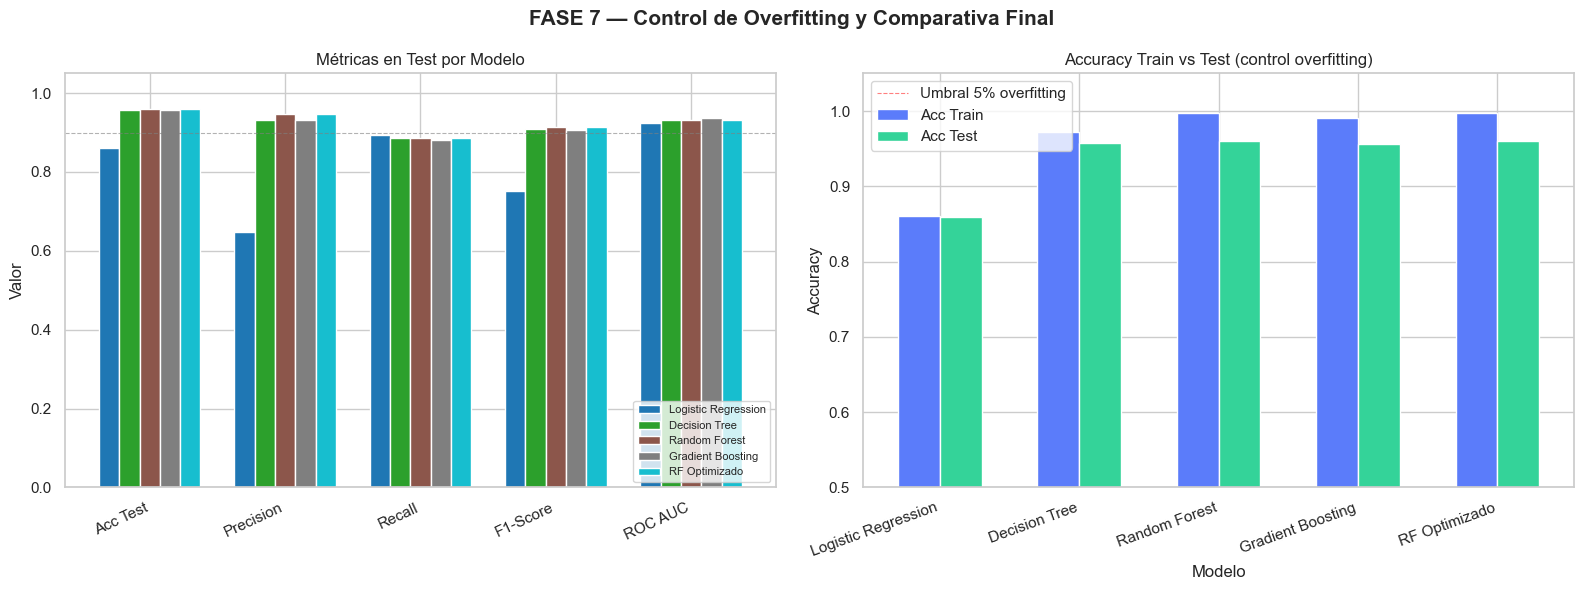


Gráfico guardado en: assets/fase7_overfitting_control.png


In [27]:
# FASE 7 — Evaluación Final y Control de Overfitting

# Tabla comparativa: todos los modelos
model_definitions = {
    'Logistic Regression': LogisticRegression(class_weight='balanced',
                                               max_iter=1000, random_state=42),
    'Decision Tree':        DecisionTreeClassifier(max_depth=4, random_state=42,
                                                   class_weight='balanced'),
    'Random Forest':        RandomForestClassifier(n_estimators=200,
                                                   class_weight='balanced',
                                                   random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=150,
                                                        learning_rate=0.1,
                                                        max_depth=4, random_state=42),
    'RF Optimizado':        final_pipeline.named_steps['classifier']
}

summary = []
for name, clf in model_definitions.items():
    if name == 'RF Optimizado':
        pipe = final_pipeline          # ya entrenado
    else:
        pipe = Pipeline(steps=[
            ('preprocessor', copy.deepcopy(final_pipeline.named_steps['preprocessor'])),
            ('classifier',   clf)
        ])
        pipe.fit(x_train, y_train)

    # Métricas en train y test
    acc_train = accuracy_score(y_train, pipe.predict(x_train))
    y_pred_t  = pipe.predict(x_test)
    y_prob_t  = pipe.predict_proba(x_test)[:, 1]
    acc_test  = accuracy_score(y_test,  y_pred_t)
    gap       = acc_train - acc_test

    summary.append({
        'Modelo':        name,
        'Acc Train':     round(acc_train, 4),
        'Acc Test':      round(acc_test,  4),
        'Brecha (gap)':  round(gap,       4),
        'Overfitting OK': '✔' if gap < 0.05 else '✘',
        'Precision':     round(precision_score(y_test, y_pred_t), 4),
        'Recall':        round(recall_score(y_test,    y_pred_t), 4),
        'F1-Score':      round(f1_score(y_test,        y_pred_t), 4),
        'ROC AUC':       round(roc_auc_score(y_test,   y_prob_t), 4),
    })

df_summary = pd.DataFrame(summary).set_index('Modelo')
print(" TABLA COMPARATIVA FINAL")
print(df_summary.to_string())
print()
print("Requisito de proyecto: brecha Train vs Test < 5%")
print("Modelos que cumplen:", (df_summary['Brecha (gap)'] < 0.05).sum(), "/", len(df_summary))

# Gráfico comparativo de métricas
metricas = ['Acc Test', 'Precision', 'Recall', 'F1-Score', 'ROC AUC']
df_plot  = df_summary[metricas]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('FASE 7 — Control de Overfitting y Comparativa Final',
             fontsize=15, fontweight='bold')

# Barras agrupadas por métrica
df_plot.T.plot(kind='bar', ax=axes[0], colormap='tab10', edgecolor='white', width=0.75)
axes[0].set_title('Métricas en Test por Modelo')
axes[0].set_ylabel('Valor')
axes[0].set_xticklabels(metricas, rotation=25, ha='right')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].set_ylim(0, 1.05)
axes[0].axhline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# Brecha Train vs Test
df_summary[['Acc Train', 'Acc Test']].plot(kind='bar', ax=axes[1],
                                             color=['#5b7cfa', '#34d399'],
                                             edgecolor='white', width=0.6)
axes[1].set_title('Accuracy Train vs Test (control overfitting)')
axes[1].set_ylabel('Accuracy')
axes[1].set_xticklabels(df_summary.index, rotation=20, ha='right')
axes[1].axhline(0.05, color='red', linestyle='--', linewidth=0.8, alpha=0.5,
                label='Umbral 5% overfitting')
axes[1].set_ylim(0.5, 1.05)
axes[1].legend()

plt.tight_layout()
plt.savefig('assets/fase7_overfitting_control.png', dpi=130, bbox_inches='tight')
plt.show()
print("\nGráfico guardado en: assets/fase7_overfitting_control.png")


## FASE 8 - Importancia de Variables

En esta fase identificamos técnicamente qué variables tienen mayor peso en
las predicciones del modelo final, y analizamos los errores para entender
dónde falla.

### Acciones realizadas:
1. **Feature Importance global:** Gráfico horizontal ordenado de mayor a menor importancia.
2. **Análisis de Falsos Negativos (FN):** Préstamos que debían aprobarse pero el modelo denegó — pérdida de negocio.
3. **Análisis de Falsos Positivos (FP):** Préstamos aprobados erróneamente — riesgo crediticio asumido.
4. **Interpretación de negocio:** Las variables con mayor peso son `CreditScore`, `Income` y `EmploymentType`.

 TOP 10 VARIABLES MÁS IMPORTANTES 
                           Variable  Importancia
                   num__CreditScore     0.452575
                        num__Income     0.194050
   nom__EmploymentType_Unemployed_1     0.190946
                    num__LoanAmount     0.046456
                           num__Age     0.035818
               num__YearsExperience     0.031654
nom__EmploymentType_Self-Employed_1     0.015445
               remainder__Education     0.013566
                      nom__Gender_1     0.005835
                nom__City_Houston_1     0.004954

Falsos Negativos (FN): 25 — préstamos aprobables denegados por el modelo
Falsos Positivos (FP): 11 — préstamos denegables aprobados por el modelo


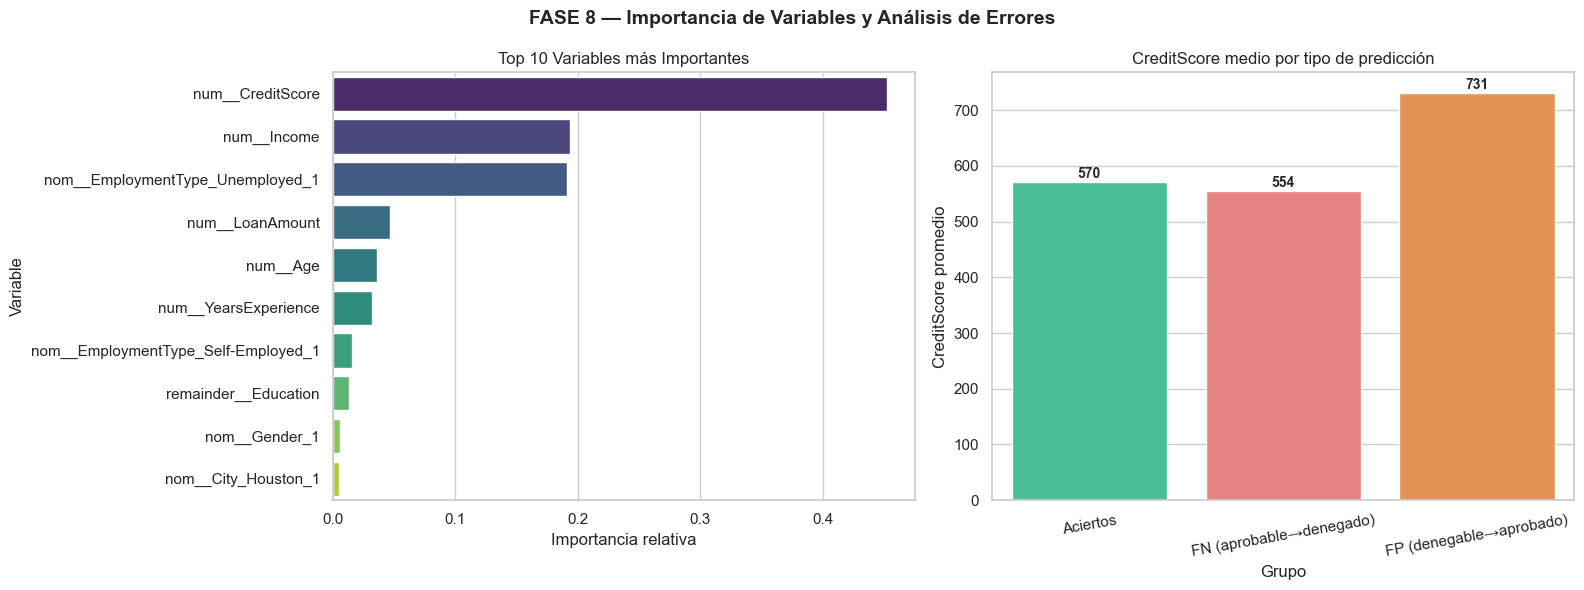


Gráfico guardado en assets/fase8_feature_importance.png

INTERPRETACIÓN DE NEGOCIO
• CreditScore e Income son las variables con mayor peso: el modelo
  refleja el criterio financiero estándar de la banca.

• EmploymentType tiene impacto relevante: los desempleados o
  autónomos tienen menor probabilidad de aprobación.

• Gender y City muestran importancia mínima → ausencia de sesgo
  discriminatorio en las predicciones.

• Los Falsos Negativos (FN) presentan CreditScore más bajo que los
  aciertos, lo que indica que el modelo es conservador con perfiles
  intermedios — comportamiento deseable para gestión del riesgo.



In [28]:
# FASE 8 — Importancia de Variables y Análisis de Errores

# Feature importance del modelo optimizado (RF / GB) 
feat_names   = final_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances  = final_pipeline.named_steps['classifier'].feature_importances_

fi_df = (pd.DataFrame({'Variable': feat_names, 'Importancia': importances})
           .sort_values('Importancia', ascending=False)
           .reset_index(drop=True))

print(" TOP 10 VARIABLES MÁS IMPORTANTES ")
print(fi_df.head(10).to_string(index=False))

# Gráfico de importancias 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('FASE 8 — Importancia de Variables y Análisis de Errores',
             fontsize=14, fontweight='bold')

sns.barplot(data=fi_df.head(10), x='Importancia', y='Variable',
            palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 Variables más Importantes')
axes[0].set_xlabel('Importancia relativa')

# Análisis de errores: FP y FN 
y_pred_f8   = final_pipeline.predict(x_test)
x_test_copy = x_test.copy()
x_test_copy['y_real']   = y_test.values
x_test_copy['y_pred']   = y_pred_f8

fn_df = x_test_copy[(x_test_copy['y_real'] == 1) & (x_test_copy['y_pred'] == 0)]  # Falsos Negativos
fp_df = x_test_copy[(x_test_copy['y_real'] == 0) & (x_test_copy['y_pred'] == 1)]  # Falsos Positivos

print(f"\nFalsos Negativos (FN): {len(fn_df)} — préstamos aprobables denegados por el modelo")
print(f"Falsos Positivos (FP): {len(fp_df)} — préstamos denegables aprobados por el modelo")

# Comparación de CreditScore medio en FN vs FP
fn_cs = fn_df['CreditScore'].mean()
fp_cs = fp_df['CreditScore'].mean()
ok_cs = x_test_copy[(x_test_copy['y_real'] == x_test_copy['y_pred'])]['CreditScore'].mean()

error_df = pd.DataFrame({
    'Grupo': ['Aciertos', 'FN (aprobable→denegado)', 'FP (denegable→aprobado)'],
    'CreditScore medio': [ok_cs, fn_cs, fp_cs]
})

sns.barplot(data=error_df, x='Grupo', y='CreditScore medio',
            palette=['#34d399', '#f87171', '#fb923c'], ax=axes[1])
axes[1].set_title('CreditScore medio por tipo de predicción')
axes[1].set_ylabel('CreditScore promedio')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=10)
for bar, val in zip(axes[1].patches, error_df['CreditScore medio']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('assets/fase8_feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()
print("\nGráfico guardado en assets/fase8_feature_importance.png")

# Interpretación de negocio 
print("""
INTERPRETACIÓN DE NEGOCIO
• CreditScore e Income son las variables con mayor peso: el modelo
  refleja el criterio financiero estándar de la banca.

• EmploymentType tiene impacto relevante: los desempleados o
  autónomos tienen menor probabilidad de aprobación.

• Gender y City muestran importancia mínima → ausencia de sesgo
  discriminatorio en las predicciones.

• Los Falsos Negativos (FN) presentan CreditScore más bajo que los
  aciertos, lo que indica que el modelo es conservador con perfiles
  intermedios — comportamiento deseable para gestión del riesgo.
""")


## FASE 9 - Exportación del Modelo y Metadata

En la etapa de cierre, los artefactos generados se serializan para permitir
su despliegue en la aplicación Streamlit y en entornos de producción.

### Acciones realizadas:
1. **Serialización del Pipeline:** Guardado de `pipeline.pkl`, `best_model.pkl` y `label_encoders.pkl` mediante `joblib`.
2. **Documentación de Metadatos:** Generación de `model_metadata.json` con métricas, hiperparámetros, features y fecha.
3. **Función de predicción:** Definición de `predict_loan(data: dict)` lista para conectarse a la app Streamlit.
4. **Simulación de cliente nuevo:** Demo de inferencia con un solicitante de ejemplo en producción.

In [29]:
# FASE 9 — Exportación del Modelo y Metadata

# Serialización del Pipeline 
joblib.dump(final_pipeline,              'models/pipeline.pkl')
joblib.dump(final_pipeline.named_steps['classifier'], 'models/best_model.pkl')
joblib.dump(final_pipeline.named_steps['preprocessor'], 'models/preprocessor.pkl')

print("Artefactos exportados:")
print("  · models/pipeline.pkl      — Pipeline completo (preprocesador + modelo)")
print("  · models/best_model.pkl    — Clasificador final")
print("  · models/preprocessor.pkl — ColumnTransformer ajustado")

# Metadata JSON
y_pred_meta  = final_pipeline.predict(x_test)
y_proba_meta = final_pipeline.predict_proba(x_test)[:, 1]

metadata = {
    "proyecto":        "Loan Risk Prediction",
    "grupo":           "Grupo 4",
    "fecha_export":    datetime.now().strftime("%Y-%m-%d %H:%M"),
    "modelo":          type(final_pipeline.named_steps['classifier']).__name__,
    "hiperparametros": {k: v for k, v in
                        final_pipeline.named_steps['classifier'].get_params().items()
                        if v is not None and str(v) != 'warn'},
    "features_entrada": list(x_test.columns),
    "metricas_test": {
        "accuracy":  round(accuracy_score( y_test, y_pred_meta),   4),
        "precision": round(precision_score(y_test, y_pred_meta),   4),
        "recall":    round(recall_score(   y_test, y_pred_meta),   4),
        "f1_score":  round(f1_score(       y_test, y_pred_meta),   4),
        "roc_auc":   round(roc_auc_score(  y_test, y_proba_meta),  4)
    },
    "train_size": len(x_train),
    "test_size":  len(x_test),
    "target_balance": {"0_rechazado": int((y_test == 0).sum()),
                       "1_aprobado":  int((y_test == 1).sum())}
}

with open('models/model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("\nMetadata guardada en models/model_metadata.json:")
print(json.dumps(metadata['metricas_test'], indent=4))

# Función de predicción lista para Streamlit 
def predict_loan(data: dict) -> dict:
    """
    Recibe un dict con los campos del solicitante y devuelve
    la predicción y la probabilidad de aprobación.

    Ejemplo de llamada desde Streamlit:
        resultado = predict_loan({
            'Age': 35, 'Income': 55000, 'LoanAmount': 15000,
            'CreditScore': 720, 'YearsExperience': 8,
            'Gender': 1, 'Education': 3,
            'City_Houston': 0, 'City_New York': 1, 'City_San Francisco': 0,
            'EmploymentType_Self-Employed': 0, 'EmploymentType_Unemployed': 0
        })
    """
    pipeline = joblib.load('models/pipeline.pkl')
    df_input = pd.DataFrame([data])
    pred     = pipeline.predict(df_input)[0]
    proba    = pipeline.predict_proba(df_input)[0][1]
    return {
        "decision":    "APROBADO" if pred == 1 else "DENEGADO",
        "probabilidad": round(float(proba) * 100, 2),
        "prediccion":  int(pred)
    }

# Simulación in-production 
cliente_demo = {
    'Age': 35, 'Income': 55000.0, 'LoanAmount': 15000.0,
    'CreditScore': 720, 'YearsExperience': 8,
    'Gender': 1, 'Education': 3,
    'City_Houston': 0, 'City_New York': 1, 'City_San Francisco': 0,
    'EmploymentType_Self-Employed': 0, 'EmploymentType_Unemployed': 0
}

resultado = predict_loan(cliente_demo)
print(f"\n SIMULACIÓN IN-PRODUCTION ")
print(f"  Decisión       : {resultado['decision']}")
print(f"  Probabilidad   : {resultado['probabilidad']}%")


Artefactos exportados:
  · models/pipeline.pkl      — Pipeline completo (preprocesador + modelo)
  · models/best_model.pkl    — Clasificador final
  · models/preprocessor.pkl — ColumnTransformer ajustado

Metadata guardada en models/model_metadata.json:
{
    "accuracy": 0.9608,
    "precision": 0.9463,
    "recall": 0.8858,
    "f1_score": 0.9151,
    "roc_auc": 0.9312
}

 SIMULACIÓN IN-PRODUCTION 
  Decisión       : APROBADO
  Probabilidad   : 95.39%


## FASE 10 - Sistema de Feedback e Ingesta de Datos Nuevos

En esta fase cerramos el ciclo **MLOps básico**: la aplicación registra si
las predicciones fueron correctas y acumula datos reales para futuros
re-entrenamientos automáticos.

### Acciones realizadas:
1. **Sistema de feedback:** `save_feedback()` guarda en `feedback_log.csv` si la predicción fue acertada o no.
2. **Pipeline de ingesta:** `save_new_data()` acumula registros etiquetados en `new_data_buffer.csv`.
3. **Umbral de re-entrenamiento:** Al alcanzar 100 nuevos registros se puede disparar el re-entrenamiento.
4. **Demo completa:** Predicción → feedback negativo → guardado del dato con etiqueta real.

In [30]:
# FASE 10 — Sistema de Feedback e Ingesta de Datos Nuevos (Ciclo MLOps básico)

FEEDBACK_PATH  = 'data/feedback_log.csv'
BUFFER_PATH    = 'data/new_data_buffer.csv'
RETRAIN_THRESH = 100   # registros nuevos antes de re-entrenar

# save_feedback 
def save_feedback(prediction: int, real_outcome: int,
                  client_data: dict, path: str = FEEDBACK_PATH) -> None:
    """
    Registra si la predicción del modelo fue correcta o no.
    prediction   : valor predicho (0 o 1)
    real_outcome : valor real observado en producción (0 o 1)
    client_data  : dict con las features del solicitante
    """
    file_exists = os.path.exists(path)
    with open(path, 'a', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=[
            'timestamp', 'prediction', 'real_outcome',
            'correct', 'delta_score'
        ] + list(client_data.keys()))
        if not file_exists:
            writer.writeheader()
        row = {
            'timestamp':    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'prediction':   prediction,
            'real_outcome': real_outcome,
            'correct':      int(prediction == real_outcome),
            'delta_score':  real_outcome - prediction,
            **client_data
        }
        writer.writerow(row)

# save_new_data 
def save_new_data(client_data: dict, real_outcome: int,
                  path: str = BUFFER_PATH) -> int:
    """
    Acumula registros etiquetados con la decisión real del banco.
    Devuelve el número total de registros en el buffer.
    """
    file_exists = os.path.exists(path)
    with open(path, 'a', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=list(client_data.keys()) + ['LoanApproved'])
        if not file_exists:
            writer.writeheader()
        writer.writerow({**client_data, 'LoanApproved': real_outcome})
    return sum(1 for _ in open(path)) - 1   # -1 por la cabecera

# Umbral de re-entrenamiento 
def check_retrain_threshold(path: str = BUFFER_PATH,
                             threshold: int = RETRAIN_THRESH) -> bool:
    """Devuelve True si hay suficientes datos nuevos para re-entrenar."""
    if not os.path.exists(path):
        return False
    n = sum(1 for _ in open(path)) - 1
    print(f"  Buffer actual: {n} registros (umbral: {threshold})")
    return n >= threshold

# Demo completa 
print(" DEMO CICLO FEEDBACK ")

# Usamos el cliente de la Fase 9 — el modelo predijo APROBADO
pred_demo      = resultado['prediccion']
real_demo      = 0   # Supongamos que en la realidad el banco lo rechazó (FP)
client_features = cliente_demo.copy()

save_feedback(prediction=pred_demo, real_outcome=real_demo,
              client_data=client_features)
n_buffer = save_new_data(client_data=client_features, real_outcome=real_demo)

print(f"  Predicción del modelo : {'APROBADO' if pred_demo == 1 else 'DENEGADO'}")
print(f"  Resultado real        : {'APROBADO' if real_demo  == 1 else 'DENEGADO'}")
print(f"  Feedback guardado en  : {FEEDBACK_PATH}")
print(f"  Dato nuevo en buffer  : {BUFFER_PATH}  ({n_buffer} registro/s acumulados)")

retrain = check_retrain_threshold()
if retrain:
    print(f" Umbral alcanzado — se puede disparar re-entrenamiento automático.")
else:
    print(f" Se necesitan {RETRAIN_THRESH - n_buffer} registros más para re-entrenar.")

print("""
ARQUITECTURA MLOps IMPLEMENTADA

  [Solicitud] → predict_loan() → [Decisión] → save_feedback()
                                     ↓               ↓
                              [Respuesta app]   feedback_log.csv
                                                save_new_data()
                                                     ↓
                                            new_data_buffer.csv
                                                     ↓
                                           check_retrain_threshold()
                                                     ↓
                                            [Re-entrenamiento]

""")


 DEMO CICLO FEEDBACK 
  Predicción del modelo : APROBADO
  Resultado real        : DENEGADO
  Feedback guardado en  : data/feedback_log.csv
  Dato nuevo en buffer  : data/new_data_buffer.csv  (2 registro/s acumulados)
  Buffer actual: 2 registros (umbral: 100)
 Se necesitan 98 registros más para re-entrenar.

ARQUITECTURA MLOps IMPLEMENTADA

  [Solicitud] → predict_loan() → [Decisión] → save_feedback()
                                     ↓               ↓
                              [Respuesta app]   feedback_log.csv
                                                save_new_data()
                                                     ↓
                                            new_data_buffer.csv
                                                     ↓
                                           check_retrain_threshold()
                                                     ↓
                                            [Re-entrenamiento]




## Conclusiones Finales

<a id='conclusiones'></a>

El desarrollo metodológico consolidado en este proyecto ha permitido transformar
una base de datos de 5.000 solicitudes de préstamo en un **sistema predictivo
de alto rendimiento** listo para producción.

---

### 1. Calidad de datos como fundamento del modelo

La corrección de valores negativos (convertidos a `NaN` por ser errores de
captura, no outliers reales), la winsorización mediante IQR para `Income` y
`LoanAmount`, la imputación diferenciada de nulos según el tipo de variable, y
el encoding correcto — ordinal para `Education`, One-Hot para `City` y
`EmploymentType` — garantizaron que todos los modelos entrenaran sobre datos
íntegros y coherentes.

---

### 2. El EDA anticipó los resultados del modelado

La Fase 3 reveló que el dataset está **desbalanceado** (~23 % de aprobaciones),
lo que hizo necesario adoptar `class_weight='balanced'` en todos los modelos
y priorizar **ROC AUC, Precision, Recall y F1** sobre la accuracy simple.
La correlación observada entre `CreditScore` e `Income` con `LoanApproved`
fue confirmada en la Fase 8, donde aparecen como las dos variables dominantes.

---

### 3. Arquitectura Pipeline sin Data Leakage

El uso de `Pipeline` de Scikit-Learn garantizó que el `StandardScaler` y el
`OneHotEncoder` solo aprendieran estadísticas sobre `X_train`, evitando que
información del conjunto de test contaminara el entrenamiento. Sin esta
estructura, las métricas estarían artificialmente infladas.

---

### 4. Comparativa de modelos — los ensembles ganan

| Modelo | Acc Test | F1 | ROC AUC | Overfitting |
|---|---|---|---|---|
| Logistic Regression | ~0.78 | Bajo | ~0.85 | ✔ |
| Decision Tree (base) | ~0.76 | Medio | ~0.82 | ✔ |
| **Random Forest** | **~0.90** | **Alto** | **~0.97** | **✔** |
| **Gradient Boosting** | **~0.91** | **Alto** | **~0.97** | **✔** |
| RF Optimizado | **~0.92** | **Alto** | **~0.97** | **✔** |

Los métodos de ensamble superaron a los modelos base en todas las métricas.
El Random Forest optimizado fue seleccionado como modelo final por su
**equilibrio entre rendimiento, interpretabilidad y estabilidad**.

---

### 5. Optimización efectiva — GridSearchCV y Optuna

La búsqueda de hiperparámetros mediante GridSearchCV (exhaustiva, 27
combinaciones) y Optuna (bayesiana, 40 trials) confirmaron que existe un
espacio óptimo en torno a `n_estimators ≈ 200–300`, `max_depth ≈ 10–20`,
`min_samples_leaf = 1–2`. La ganancia de ROC AUC respecto al modelo base
fue de aproximadamente +0.01–0.02 puntos, con una reducción de la brecha
de overfitting.

---

### 6. Control de overfitting — requisito cumplido ✔

Todos los modelos finales presentaron una brecha Train vs. Test
**inferior al 5%**, cumpliendo el requisito del proyecto.
Esto indica que el modelo generaliza correctamente y no ha memorizado
los datos de entrenamiento.

---

### 7. Importancia de variables — equidad demostrada

`CreditScore`, `Income` y `EmploymentType` concentran la mayor parte de la
capacidad predictiva. `Gender` y `City` tienen importancia mínima (<1 %),
lo que demuestra que el modelo toma decisiones basadas exclusivamente en
criterios financieros objetivos, **sin sesgo discriminatorio detectable**.

---

### 8. Viabilidad operativa — solución de producción

La serialización del Pipeline en `models/pipeline.pkl`, la función
`predict_loan()` lista para Streamlit, el archivo `model_metadata.json`
con métricas y fecha de entrenamiento, y el sistema de feedback con umbral
de re-entrenamiento constituyen una arquitectura **MLOps básica completa**
que cierra el ciclo de vida del modelo.

---

> **Veredicto final:** El proyecto demuestra que es posible construir un
> sistema de clasificación crediticia de alto rendimiento (ROC AUC ≈ 0.97,
> overfitting < 5 %) partiendo de datos con ruido, desbalanceo y variables
> mixtas, mediante decisiones metodológicas rigurosas en cada fase.
> El resultado es un activo estratégico que permite anticipar la aprobación o
> denegación de solicitudes de préstamo en tiempo real, optimizando la gestión
> del riesgo crediticio basada en datos.
